# Automated Vehicle Damage Triage for Insurance Claims  

datset: [VehiDE Dataset](https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection)  
**Stage 1**: Damage presence / type classifier

* Predict broad damage categories such as dent, scratch, crack, broken part, or severity bucket.

**Stage 2:** Damage localization

* Add bounding-box or segmentation-based localization if annotations exist, because ControlExpert publicly highlights vehicle-part segmentation and precise damage detection rather than image-level labels only.

## 1-Data ingestion

In [ ]:
# # Download data
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection")

# print("Path to dataset files:", path)

In [41]:
from utils import walk_through_dir

walk_through_dir("VehiDe_dataset")

There are 2 directories and 2 images/files in 'VehiDe_dataset'.
There are 1 directories and 0 images/files in 'VehiDe_dataset/image'.
There are 0 directories and 11621 images/files in 'VehiDe_dataset/image/image'.
There are 1 directories and 0 images/files in 'VehiDe_dataset/validation'.
There are 0 directories and 2324 images/files in 'VehiDe_dataset/validation/validation'.


Annotated images found: 11621


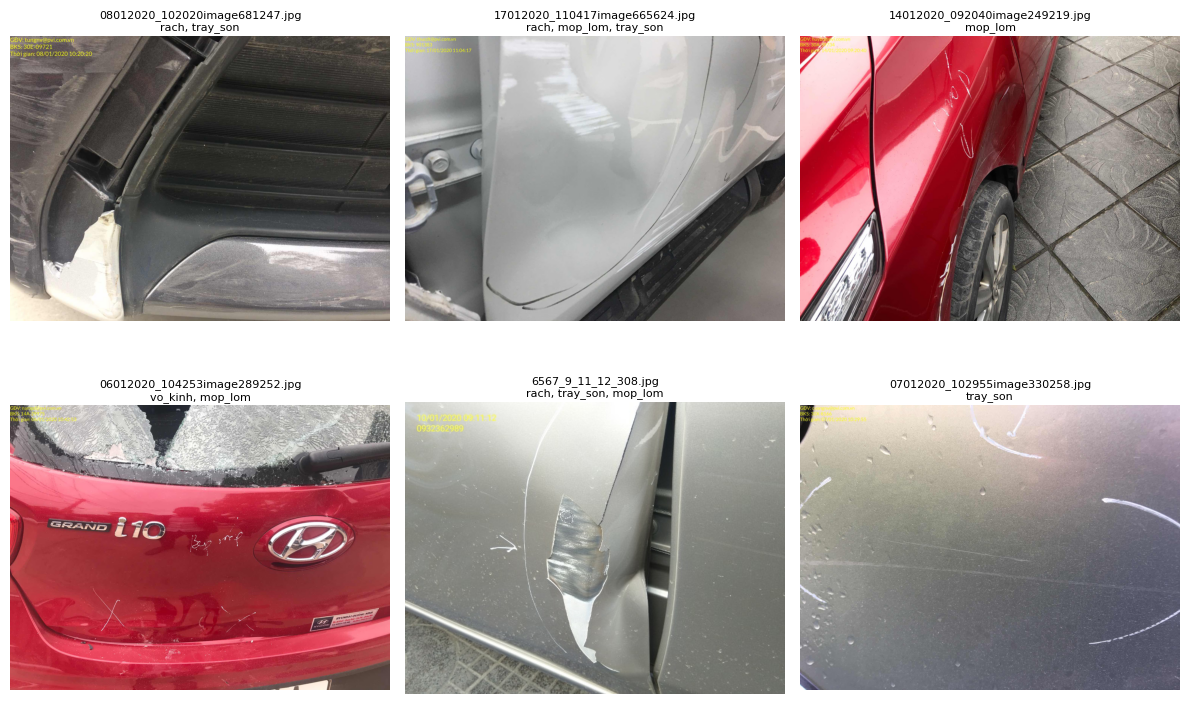

In [44]:
%matplotlib inline
from utils import plot_random_images_with_labels

plot_random_images_with_labels(
    json_path="VehiDe_dataset/0Train_via_annos.json",
    images_dir="VehiDe_dataset/image/image",
    num_samples=6,
    n_cols=3)

In [45]:
from utils import get_unique_labels

train_labels = get_unique_labels("VehiDe_dataset/0Train_via_annos.json")
val_labels   = get_unique_labels("VehiDe_dataset/0Val_via_annos.json")

Total unique labels: 7
Label                   Count
------------------------------
tray_son                12267
mop_lom                  4709
rach                     4546
mat_bo_phan              2370
be_den                   2324
thung                    2006
vo_kinh                  1824
Total unique labels: 7
Label                   Count
------------------------------
tray_son                 2380
mop_lom                   972
rach                      963
be_den                    458
mat_bo_phan               448
thung                     417
vo_kinh                   397


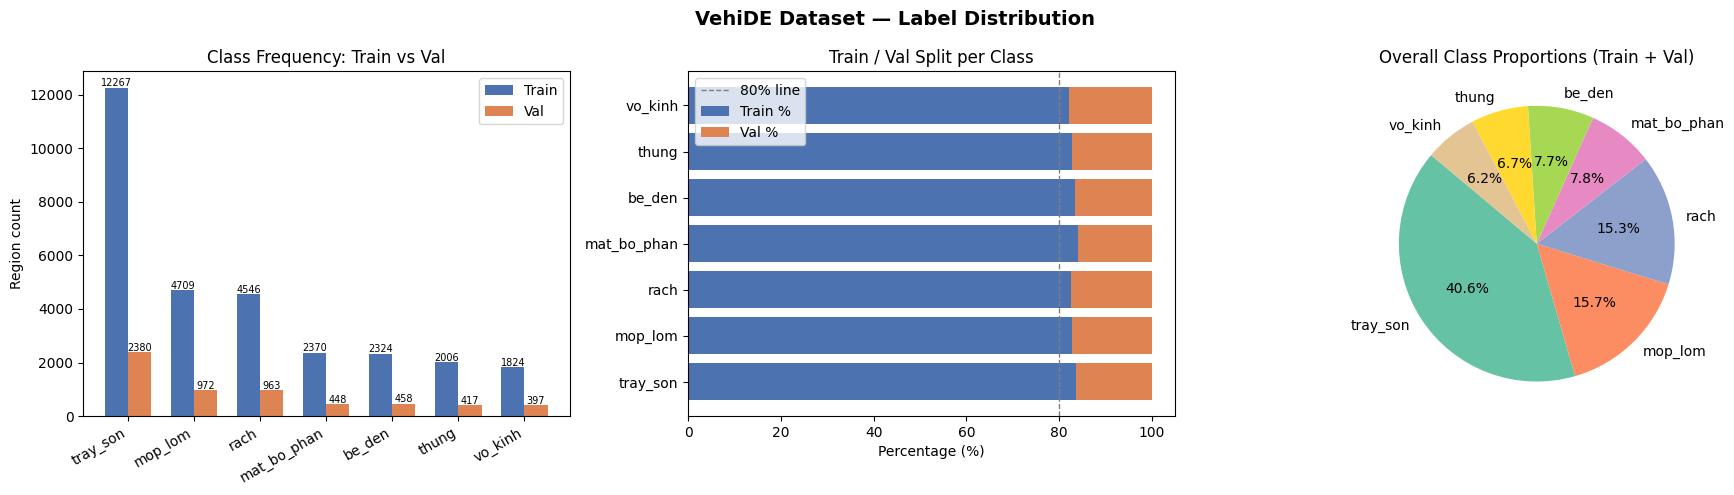

In [46]:
from utils import plot_label_distribution

plot_label_distribution(
    train_json="VehiDe_dataset/0Train_via_annos.json",
    val_json="VehiDe_dataset/0Val_via_annos.json")

In [47]:
from PIL import Image
import numpy as np
from pathlib import Path
from collections import Counter

images_dir = Path("VehiDe_dataset/image/image")

widths, heights, modes = [], [], []
for img_path in images_dir.glob("*.jpg"):
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    modes.append(img.mode)

print(f"Total images checked: {len(widths)}")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Color modes: {Counter(modes)}")

Total images checked: 11621
Width  — min: 204, max: 2365, mean: 1375
Height — min: 153, max: 2560, mean: 1024
Color modes: Counter({'RGB': 11369, 'RGBA': 252})


In [48]:
import numpy as np
from PIL import Image
from pathlib import Path

img_path = next(Path("VehiDe_dataset/image/image").glob("*.jpg"))
img = Image.open(img_path).convert("RGB")
arr = np.array(img)

print(f"dtype:  {arr.dtype}")
print(f"min:    {arr.min()}")
print(f"max:    {arr.max()}")
print(f"shape:  {arr.shape}")

dtype:  uint8
min:    0
max:    255
shape:  (600, 800, 3)


## 2- Base_model with ultralytics


In [ ]:
# Convert this VehiDe unstructure to YOLO structure format Also translate labels to english
import json
import shutil
from pathlib import Path

# ── config ──────────────────────────────────────────────
SRC_IMAGES_TRAIN = Path("VehiDe_dataset/image/image")
SRC_IMAGES_VAL   = Path("VehiDe_dataset/validation/validation")
TRAIN_JSON       = Path("VehiDe_dataset/0Train_via_annos.json")
VAL_JSON         = Path("VehiDe_dataset/0Val_via_annos.json")
OUT_DIR          = Path("yolo_dataset")
# ────────────────────────────────────────────────────────

LABEL_MAP = {
    "tray_son":    "paint_scratch",
    "mop_lom":     "dented",
    "rach":        "crack",
    "mat_bo_phan": "missing_parts",
    "be_den":      "crushed_panel",
    "thung":       "punctured",
    "vo_kinh":     "broken_glass",
}

def get_all_classes(*json_paths):
    classes = set()
    for jp in json_paths:
        with open(jp) as f:
            data = json.load(f)
        for entry in data.values():
            for region in entry["regions"]:
                eng = LABEL_MAP.get(region["class"], region["class"])
                classes.add(eng)
    return sorted(classes)

def convert_split(json_path, src_images_dir, split):
    with open(json_path) as f:
        data = json.load(f)

    img_out = OUT_DIR / "images" / split
    lbl_out = OUT_DIR / "labels" / split
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    from PIL import Image  # import once here

    converted = 0
    for fname, entry in data.items():
        src = src_images_dir / fname
        if not src.exists():
            print(f"Missing: {src}")
            continue

        dst_img = img_out / fname
        dst_lbl = lbl_out / (Path(fname).stem + ".txt")

        # If both image and label already exist, skip this file
        if dst_img.exists() and dst_lbl.exists():
            continue

        # copy image if needed
        if not dst_img.exists():
            shutil.copy(src, dst_img)

        # get image size for normalization
        w, h = Image.open(src).size

        # write / overwrite label file
        lines = []
        for region in entry["regions"]:
            raw_class = region["class"]
            eng_class = LABEL_MAP.get(raw_class, raw_class)
            cls_id = class_to_id[eng_class]

            xs = [x / w for x in region["all_x"]]
            ys = [y / h for y in region["all_y"]]
            coords = [f"{x:.6f} {y:.6f}" for x, y in zip(xs, ys)]
            lines.append(f"{cls_id} " + " ".join(coords))

        dst_lbl.write_text("\n".join(lines))
        converted += 1

    print(f"[{split}] processed entries: {len(data)}, newly converted: {converted}")

# ── idempotent guard ────────────────────────────────────
dataset_yaml = OUT_DIR / "dataset.yaml"
if dataset_yaml.exists():
    print(f"{dataset_yaml} already exists — skipping conversion. "
          f"Delete it (and/or yolo_dataset) if you want to regenerate.")
else:
    # build class map
    all_classes = get_all_classes(TRAIN_JSON, VAL_JSON)
    class_to_id = {cls: i for i, cls in enumerate(all_classes)}
    print("Classes:", class_to_id)

    # convert both splits
    convert_split(TRAIN_JSON, SRC_IMAGES_TRAIN, "train")
    convert_split(VAL_JSON,   SRC_IMAGES_VAL,   "val")

    # write dataset.yaml
    yaml_content = f"""path: {OUT_DIR.resolve()}
train: images/train
val: images/val

nc: {len(all_classes)}
names: {all_classes}
"""
    dataset_yaml.write_text(yaml_content)
    print("dataset.yaml written")
    print("All done!")

In [ ]:
# !yolo settings tensorboard=True

In [ ]:
# !nvidia-smi

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

In [ ]:
from ultralytics import YOLO

# segmentation model, not detection
model = YOLO("yolo11n-seg.pt")   # or "yolov8n-seg.pt" depending on version

model.train(
    data="yolo_dataset/dataset.yaml",
    epochs=100,
    imgsz=640,
    batch=32,
    patience=5,
    device=0,
    workers=8,
    cache=True,
    project="runs/vehide",
    name="yolo11n-seg-vehide",
)

In [ ]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
from pathlib import Path

model = YOLO("runs/segment/runs/vehide/yolo11n-seg-vehide/weights/best.pt")

img_path = "/home/paminidigehsara/Desktop/controlEx_prep/tests/Projects/Project02: VehiDE/test2.jpg"
results = model.predict(
    source=img_path,
    conf=0.25,
    retina_masks=True,
    save=False
)

r = results[0]
annotated = r.plot(boxes=True, labels=True, conf=True)
display(Image.fromarray(annotated))

### Results

In [ ]:
# 1. Get validation metrics from the trained model

from ultralytics import YOLO

model = YOLO("/home/paminidigehsara/Desktop/controlEx_prep/tests/Projects/Project02: VehiDE/runs/segment/runs/vehide/yolo11n-seg-vehide/weights/best.pt")

# run validation on the same data config
results = model.val(data="yolo_dataset/dataset.yaml")

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/home/paminidigehsara/Desktop/controlEx_prep/tests/Projects/Project02: VehiDE/runs/segment/val/confusion_matrix.png"

img = Image.open(img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO11n-Seg Confusion Matrix (VehiDE)")
plt.show()

from IPython.display import Image, display

display(Image(filename=img_path))

## Maskrcnn

In [ ]:
# # Conversion script for masrcnn format
# import json
# import shutil
# from pathlib import Path
# from PIL import Image

# # ── config ──────────────────────────────────────────────
# SRC_IMAGES_TRAIN = Path("VehiDe_dataset/image/image")
# SRC_IMAGES_VAL   = Path("VehiDe_dataset/validation/validation")
# TRAIN_JSON       = Path("VehiDe_dataset/0Train_via_annos.json")
# VAL_JSON         = Path("VehiDe_dataset/0Val_via_annos.json")
# OUT_DIR          = Path("maskrcnn_dataset")
# # ────────────────────────────────────────────────────────

# LABEL_MAP = {
#     "tray_son":    "paint_scratch",
#     "mop_lom":     "dented",
#     "rach":        "crack",
#     "mat_bo_phan": "missing_parts",
#     "be_den":      "crushed_panel",
#     "thung":       "punctured",
#     "vo_kinh":     "broken_glass",
# }

# def get_all_classes(*json_paths):
#     classes = set()
#     for jp in json_paths:
#         with open(jp, "r", encoding="utf-8") as f:
#             data = json.load(f)
#         for entry in data.values():
#             for region in entry.get("regions", []):
#                 eng = LABEL_MAP.get(region["class"], region["class"])
#                 classes.add(eng)
#     return sorted(classes)

# def convert_split(json_path, src_images_dir, split, class_to_id):
#     with open(json_path, "r", encoding="utf-8") as f:
#         data = json.load(f)

#     img_out = OUT_DIR / "images" / split
#     ann_out = OUT_DIR / "annotations" / split
#     img_out.mkdir(parents=True, exist_ok=True)
#     ann_out.mkdir(parents=True, exist_ok=True)

#     converted = 0

#     for fname, entry in data.items():
#         src = src_images_dir / fname
#         if not src.exists():
#             print(f"Missing image: {src}")
#             continue

#         dst_img = img_out / fname
#         dst_ann = ann_out / f"{Path(fname).stem}.json"

#         if not dst_img.exists():
#             shutil.copy2(src, dst_img)

#         with Image.open(src) as im:
#             width, height = im.size

#         objects = []
#         for region in entry.get("regions", []):
#             raw_class = region["class"]
#             eng_class = LABEL_MAP.get(raw_class, raw_class)

#             xs = region["all_x"]
#             ys = region["all_y"]

#             if len(xs) < 3 or len(ys) < 3 or len(xs) != len(ys):
#                 continue

#             polygon = [[float(x), float(y)] for x, y in zip(xs, ys)]

#             objects.append({
#                 "label": eng_class,
#                 "label_id": class_to_id[eng_class],
#                 "polygon": polygon,
#             })

#         sample = {
#             "image": fname,
#             "width": width,
#             "height": height,
#             "objects": objects,
#         }

#         dst_ann.write_text(json.dumps(sample, ensure_ascii=False, indent=2), encoding="utf-8")
#         converted += 1

#     print(f"[{split}] processed entries: {len(data)}, converted: {converted}")

# metadata_path = OUT_DIR / "metadata.json"

# all_classes = get_all_classes(TRAIN_JSON, VAL_JSON)
# class_to_id = {cls: i + 1 for i, cls in enumerate(all_classes)}  # 0 reserved for background

# print("Classes:", class_to_id)

# convert_split(TRAIN_JSON, SRC_IMAGES_TRAIN, "train", class_to_id)
# convert_split(VAL_JSON, SRC_IMAGES_VAL, "val", class_to_id)

# metadata = {
#     "num_classes": len(all_classes) + 1,  # include background
#     "background_id": 0,
#     "classes": ["__background__"] + all_classes,
#     "class_to_id": {"__background__": 0, **class_to_id},
#     "label_map": LABEL_MAP,
# }

# metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
# print(f"Saved metadata to {metadata_path}")
# print("Mask R-CNN dataset conversion done.")

In [ ]:
# # Dataset class for training
# # The next step is the actual PyTorch dataset class. 
# # TorchVision’s tutorial expects one image plus a target dict, and masks_to_boxes can generate [x1, y1, x2, y2] boxes
# # directly from binary masks.
# import json
# from pathlib import Path

# import numpy as np
# import torch
# from PIL import Image, ImageDraw
# from torchvision.io import read_image
# from torchvision.ops import masks_to_boxes
# from torchvision import tv_tensors
# from torchvision.transforms.v2 import functional as F

# class VehiDeMaskRCNNDataset(torch.utils.data.Dataset):
#     def __init__(self, root, split="train", transforms=None):
#         self.root = Path(root)
#         self.split = split
#         self.transforms = transforms

#         self.image_dir = self.root / "images" / split
#         self.ann_dir = self.root / "annotations" / split
#         self.ann_files = sorted(self.ann_dir.glob("*.json"))

#         metadata = json.loads((self.root / "metadata.json").read_text(encoding="utf-8"))
#         self.classes = metadata["classes"]
#         self.class_to_id = metadata["class_to_id"]

#     def __len__(self):
#         return len(self.ann_files)

#     def polygon_to_mask(self, polygon, width, height):
#         mask = Image.new("L", (width, height), 0)
#         draw = ImageDraw.Draw(mask)
#         draw.polygon([tuple(p) for p in polygon], outline=1, fill=1)
#         return np.array(mask, dtype=np.uint8)

#     def __getitem__(self, idx):
#         ann_path = self.ann_files[idx]
#         ann = json.loads(ann_path.read_text(encoding="utf-8"))

#         img_path = self.image_dir / ann["image"]
#         from PIL import Image
#         import numpy as np
#         import torch
#         from torchvision import tv_tensors

#         pil_img = Image.open(img_path).convert("RGB")
#         img = torch.from_numpy(np.array(pil_img)).permute(2, 0, 1).contiguous()
#         img = tv_tensors.Image(img)

#         width = ann["width"]
#         height = ann["height"]
#         objects = ann["objects"]

#         masks_list = []
#         labels_list = []

#         for obj in objects:
#             polygon = obj["polygon"]
#             mask = self.polygon_to_mask(polygon, width, height)
#             if mask.sum() == 0:
#                 continue
#             masks_list.append(mask)
#             labels_list.append(int(obj["label_id"]))

#         if len(masks_list) == 0:
#             masks = torch.zeros((0, height, width), dtype=torch.uint8)
#             boxes = torch.zeros((0, 4), dtype=torch.float32)
#             labels = torch.zeros((0,), dtype=torch.int64)
#             area = torch.zeros((0,), dtype=torch.float32)
#         else:
#             masks = torch.as_tensor(np.stack(masks_list), dtype=torch.uint8)
#             boxes = masks_to_boxes(masks)
#             labels = torch.as_tensor(labels_list, dtype=torch.int64)
#             area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

#         iscrowd = torch.zeros((len(labels),), dtype=torch.int64)

#         img = tv_tensors.Image(img)
#         target = {
#             "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img)),
#             "labels": labels,
#             "masks": tv_tensors.Mask(masks),
#             "image_id": idx,
#             "area": area,
#             "iscrowd": iscrowd,
#         }

#         if self.transforms is not None:
#             img, target = self.transforms(img, target)

#         return img, target

#     def get_height_and_width(self, idx):
#         ann = json.loads(self.ann_files[idx].read_text(encoding="utf-8"))
#         return ann["height"], ann["width"]

In [ ]:
# # Model and transforms

# import torch
# import torchvision
# from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
# from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
# from torchvision.transforms import v2 as T

# def get_transform(train):
#     transforms = []
#     if train:
#         transforms.append(T.RandomHorizontalFlip(0.5))
#     transforms.append(T.ToDtype(torch.float, scale=True))
#     transforms.append(T.ToPureTensor())
#     return T.Compose(transforms)

# def get_model_instance_segmentation(num_classes):
#     model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

#     in_features = model.roi_heads.box_predictor.cls_score.in_features
#     model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

#     in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
#     hidden_layer = 256
#     model.roi_heads.mask_predictor = MaskRCNNPredictor(
#         in_features_mask,
#         hidden_layer,
#         num_classes
#     )
#     return model

# def collate_fn(batch):
#     return tuple(zip(*batch))

In [ ]:
# import json
# from pathlib import Path

# import torch
# from torch.utils.data import DataLoader
# from tqdm.auto import tqdm  # <= add this


# DATA_ROOT = "maskrcnn_dataset"
# OUTPUT_DIR = Path("runs/vehide_maskrcnn")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# metadata = json.loads((Path(DATA_ROOT) / "metadata.json").read_text(encoding="utf-8"))
# num_classes = metadata["num_classes"]

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# train_dataset = VehiDeMaskRCNNDataset(DATA_ROOT, split="train", transforms=get_transform(train=True))
# val_dataset   = VehiDeMaskRCNNDataset(DATA_ROOT, split="val",   transforms=get_transform(train=False))

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=2,
#     shuffle=True,
#     num_workers=8,
#     collate_fn=collate_fn,
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=1,
#     shuffle=False,
#     num_workers=4,
#     collate_fn=collate_fn,
# )

# model = get_model_instance_segmentation(num_classes).to(device)

# params = [p for p in model.parameters() if p.requires_grad]
# optimizer = torch.optim.SGD(
#     params,
#     lr=0.005,
#     momentum=0.9,
#     weight_decay=0.0005,
# )

# lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# num_epochs = 100
# best_loss = float("inf")
# patience = 5
# patience_counter = 0

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0

#     # progress bar over training batches
#     train_pbar = tqdm(
#         train_loader,
#         desc=f"Epoch {epoch+1}/{num_epochs}",
#         unit="batch",
#         leave=False,      # set True if you want to keep every epoch bar
#     )

#     for images, targets in train_pbar:
#         images = [img.to(device) for img in images]
#         targets = [
#             {k: v.to(device) if hasattr(v, "to") else v for k, v in t.items()}
#             for t in targets
#         ]

#         loss_dict = model(images, targets)
#         losses = sum(loss for loss in loss_dict.values())

#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#         running_loss += losses.item()
#         avg_loss = running_loss / max(1, train_pbar.n)

#         # update bar postfix with current average loss
#         train_pbar.set_postfix(loss=f"{avg_loss:.4f}")

#     epoch_loss = running_loss / max(len(train_loader), 1)
#     lr_scheduler.step()

#     print(f"\nEpoch [{epoch+1}/{num_epochs}] loss={epoch_loss:.4f}")

#     checkpoint = {
#         "epoch": epoch + 1,
#         "model_state_dict": model.state_dict(),
#         "optimizer_state_dict": optimizer.state_dict(),
#         "loss": epoch_loss,
#         "classes": metadata["classes"],
#     }
#     torch.save(checkpoint, OUTPUT_DIR / "last.pth")

#     if epoch_loss < best_loss:
#         best_loss = epoch_loss
#         patience_counter = 0
#         torch.save(checkpoint, OUTPUT_DIR / "best.pth")
#     else:
#         patience_counter += 1

#     if patience_counter >= patience:
#         print(f"Early stopping at epoch {epoch+1}")
#         break